## STUDENT PERFORMANCE INDICATOR


 ### Life cycle of Machine learning Project

* Understanding the Problem Statement
* Data Collection
* Data Checks to perform
* Exploratory data analysis
* Data Pre-Processing
* Model Training
* Choose best model

## 1) Problem statement

* This project understands how the student's performance(test score) is affected by other variables such as Gender,Ethnicity,Parental level of education,Lunch and Test preparation course

## 2) Data Collection
* Dataset Source- https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
* The data consists of 8 column and 1000 rows

### 2.1 Import Data and Required Packages
** Importing Pandas,Numpy,Matplotlib,Seaborn and Warnings Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Import the CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv('data/stud.csv')

### Show Top 5 Records

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Shape of the dataset

In [4]:
df.shape

(1000, 8)

### 2.2 Dataset information

* gender: sex of students->(Male/female)
* race/ethnicity:ethnicity of students ->(Group A,B,C,D,E
)
* parental level of education : parent's final education->(bachelor's degree,some college,master's degree,associate's degree,high school)
* lunch:having lunch before test(standard or free/reduced)
* test preparation course:complete or not complete before test
* math score
* reading score
* writing score

### 3.Data Checks to perform

* Check Missing values
* Check Duplicates
* Check data type
* Check the number of unique values of each column
* Check statistics of data set
* Check various categories present in the different catgorical column

### 3.1 Check Missing values

In [5]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

#### There are no missing values in the data set

### 3.2 Check Duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicates in dataset

### 3.3 Check Data Types

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### 3.4 Checking the number of Unique values of each column

In [8]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 3.5 Check Statistics of Data

In [9]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
* From above description of numerical data,all means are very close to each other-between 66 and 68.05;
* All standard deviations are close between 14.06 and 15.19
* While there is a minimum score 0 for math,for writing minimum score = 10 and for reading minimum is much higher = 17

### 3.6 Exploring Data

In [10]:
print("Categories in 'gender' variable: ",end="")
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable: ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in 'parental level of education' variable:",end = " ")
print(df['parental_level_of_education'].unique())

print("Categorical in 'lunch' variable: ",end = " ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ",end = " ")
print(df['test_preparation_course'].unique())

Categories in 'gender' variable: ['female' 'male']
Categories in 'race_ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categorical in 'lunch' variable:  ['standard' 'free/reduced']
Categories in 'test preparation course' variable:  ['none' 'completed']


In [11]:
# define numerical & categorical columns
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'object']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'object']

#print columns
print('we have {} numerical features :{}'.format(len(numerical_features),numerical_features))
print('\nWe have {} categorical features: {}'.format(len(categorical_features),categorical_features))




we have 3 numerical features :['math_score', 'reading_score', 'writing_score']

We have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### 3.7 Adding columns for "Total Score" and "Average"

In [12]:
df['Total Score'] = df['math_score']+df['reading_score']+df['writing_score']
df['Average'] = df['Total Score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [13]:
reading_full = df[df['reading_score'] == 100]['Average'].count()
writing_full = df[df['writing_score'] == 100]['Average'].count()
math_full = df[df['math_score'] == 100]['Average'].count()
print(f'Number of students with full marks in Reading: {reading_full}')
print(f'Number of students with full marks in writing:{writing_full}')
print(f'Number of students with full marks in maths:{math_full}')

Number of students with full marks in Reading: 17
Number of students with full marks in writing:14
Number of students with full marks in maths:7


In [14]:
reading_less_20 = df[df['reading_score'] <= 20]['Average'].count()
writing_less_20 = df[df['writing_score'] <= 20]['Average'].count()
math_less_20 = df[df['math_score'] <= 20]['Average'].count()

print(f'Number of students with less than 20 marks in reading :{reading_less_20}')
print(f'Number of students with less than 20 marks in writing:{writing_less_20}')
print(f'Number of students with less than 20 marks in maths:{math_less_20}')

Number of students with less than 20 marks in reading :1
Number of students with less than 20 marks in writing:3
Number of students with less than 20 marks in maths:4


#### Insight
* From above values we get students have performed the worst in Maths
* Best performance is in reading section

## 4.Exploring Data(Visualization)

### 4.1 Visualize average score and total score distribution to make some conclusion

* Histogram
* Kernel Distribution Function(KDE)

### 4.1.1 Histogram & KDE

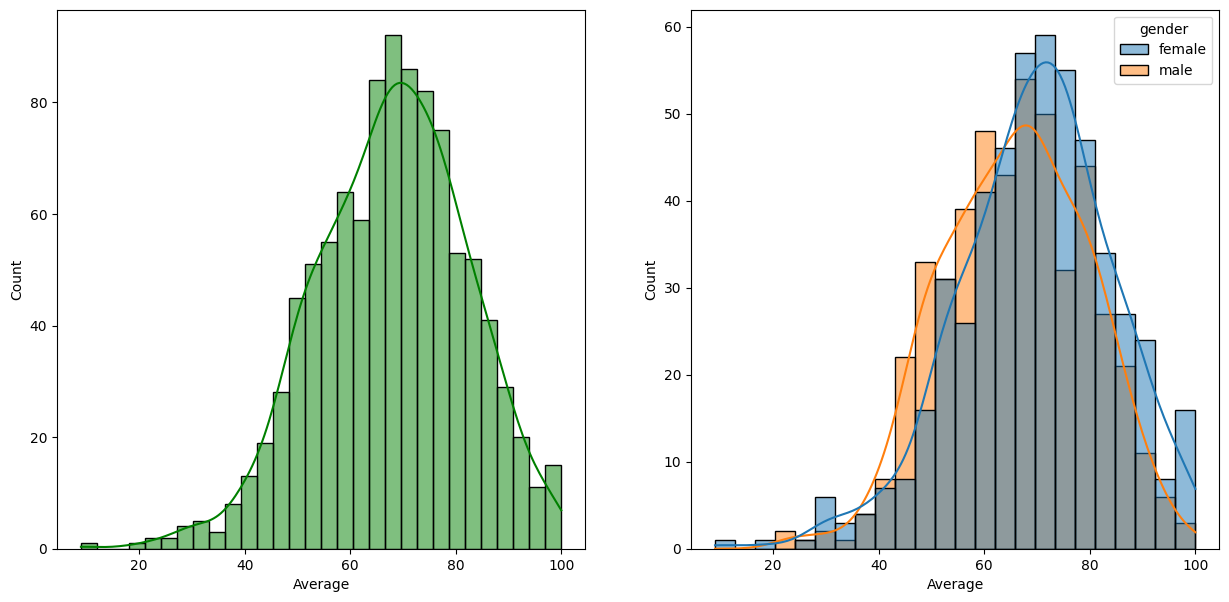

In [15]:
fig,axs = plt.subplots(1,2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x = 'Average',bins = 30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Average',kde = True,hue='gender')
plt.show()

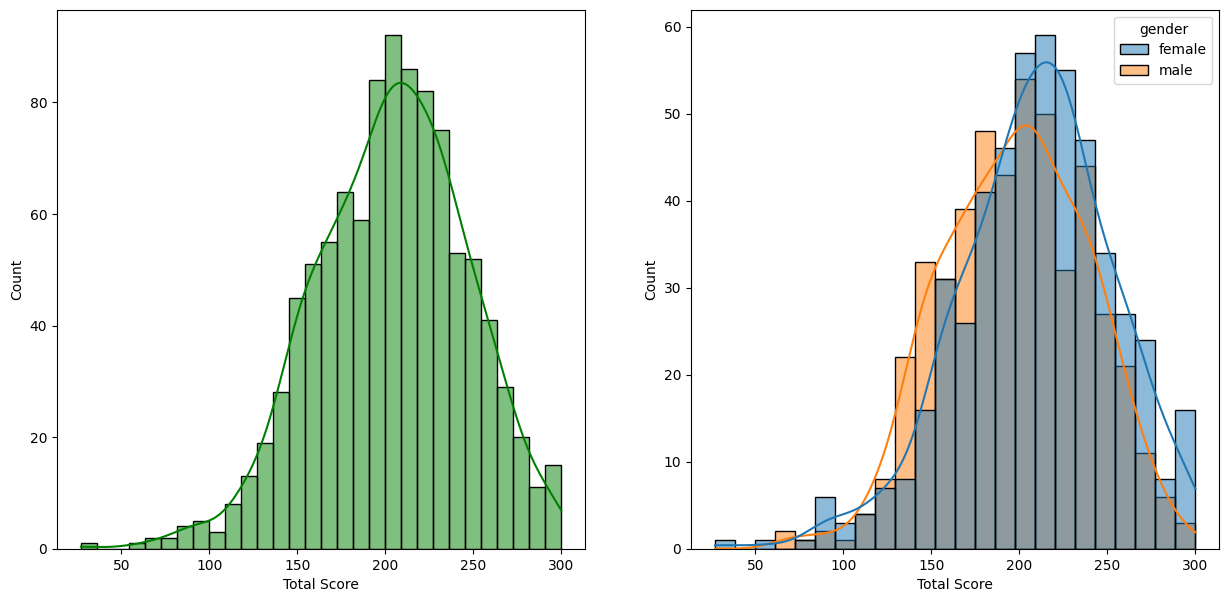

In [16]:
fig,axs = plt.subplots(1,2, figsize =(15,7))
plt.subplot(121)
sns.histplot(data = df,x='Total Score', bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Total Score',kde=True,hue='gender')
plt.show()


#### Insights
* Female students tend to perform well then male students.

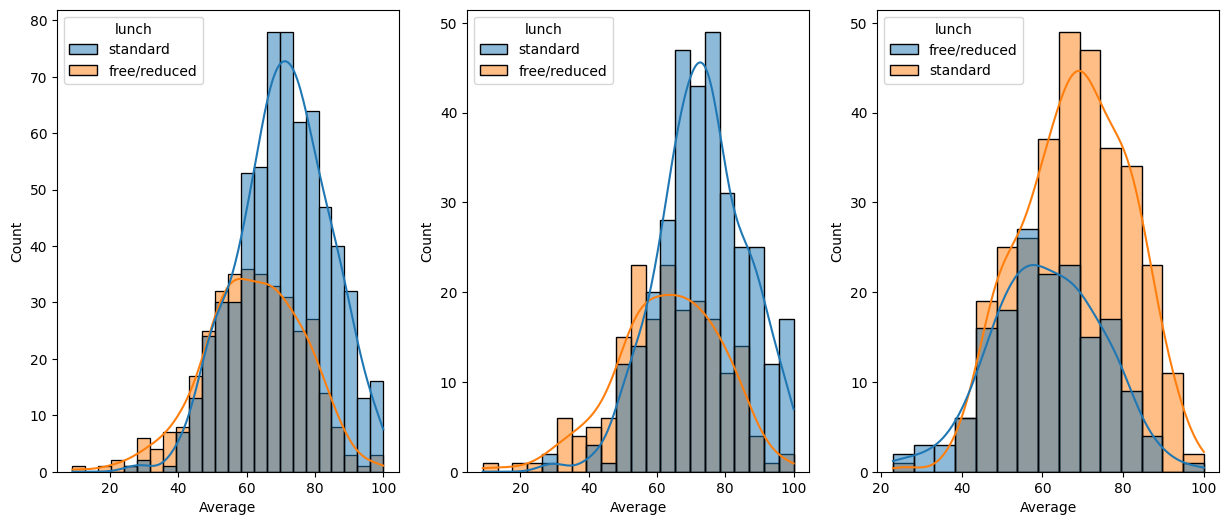

In [26]:
plt.subplots(1,3,figsize=(15,6))
plt.subplot(131)
sns.histplot(data=df,x='Average',kde=True,hue='lunch')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='Average',kde=True,hue='lunch')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x = 'Average',kde=True,hue='lunch')
plt.show()

### Insights
* Standard lunch helps perform well in exams
* Standard lunch helps perform well in exams be it a male or female

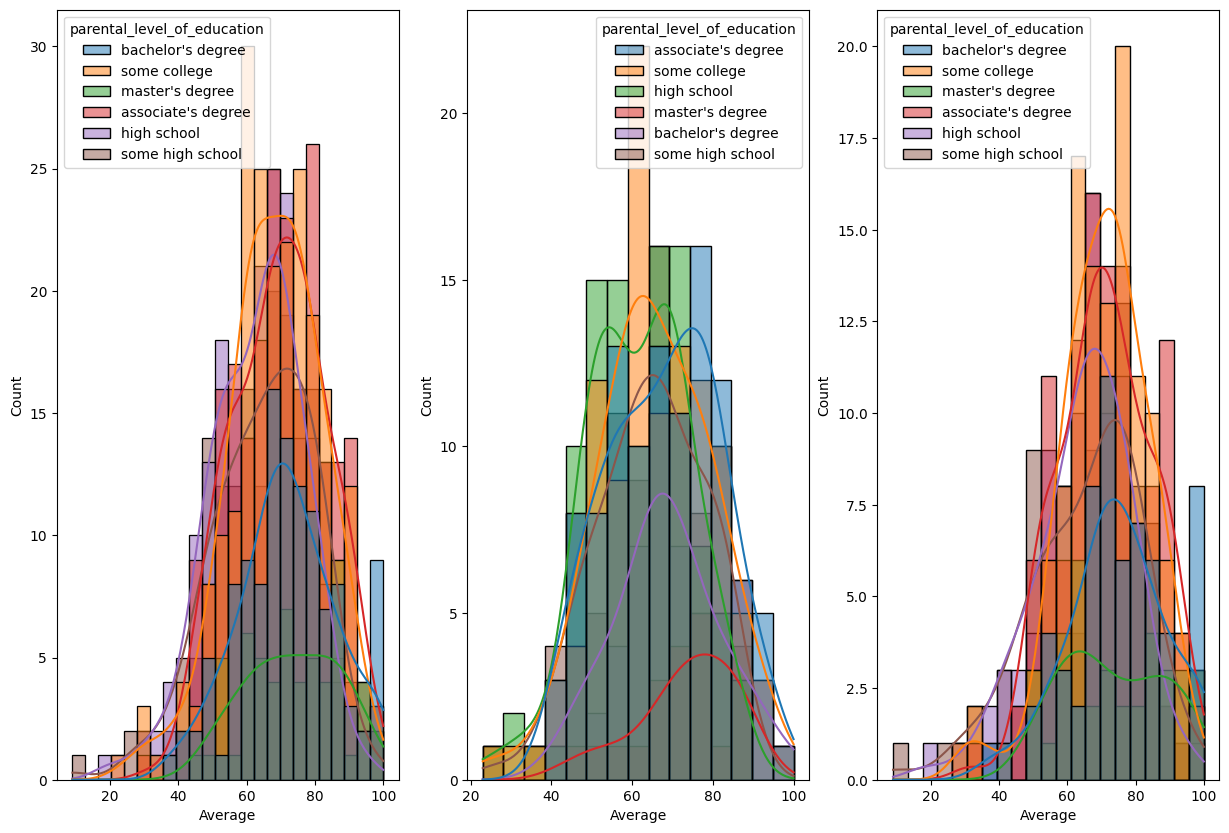

In [33]:
plt.subplots(1,3,figsize=(15,10))
plt.subplot(131)
ax = sns.histplot(data=df,x='Average',kde=True,hue='parental_level_of_education')
plt.subplot(132)
ax=sns.histplot(data=df[df.gender=='male'],x='Average',kde=True,hue='parental_level_of_education')
plt.subplot(133)
ax=sns.histplot(data=df[df.gender=='female'],x='Average',kde=True,hue='parental_level_of_education')
plt.show()

#### Insights
* In general parent's education don't help student perform well in exam.
* 2nd plot shows that parent's whose education is of associate'degree or master's degree their male chilld tend to perform well in exam
* 3rd plot we can see there is no effect of parent's education on female students.

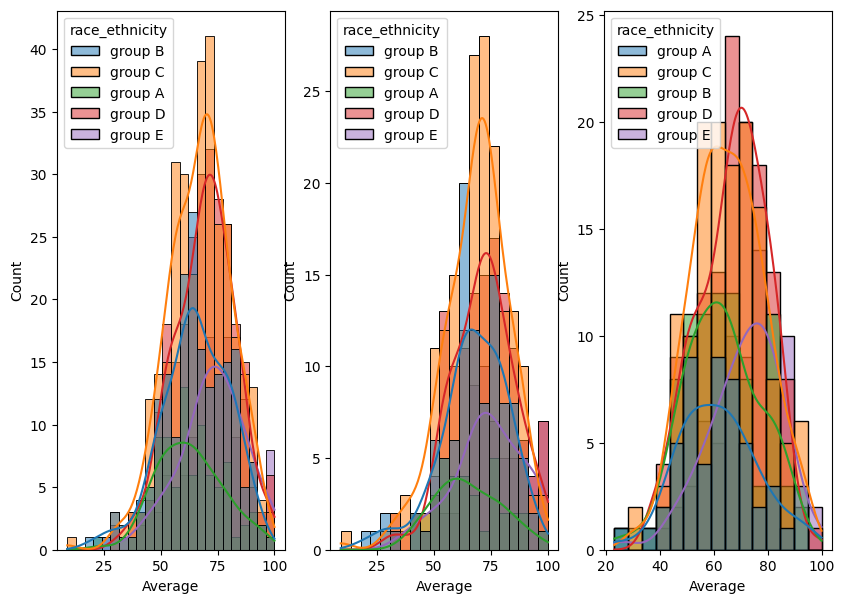

In [38]:
plt.subplots(1,3,figsize=(10,7))
plt.subplot(131)
ax = sns.histplot(data=df,x='Average',kde=True,hue='race_ethnicity')
plt.subplot(132)
ax=sns.histplot(data=df[df.gender=='female'],x='Average',kde=True,hue='race_ethnicity')
plt.subplot(133)
ax = sns.histplot(data=df[df.gender=='male'],x='Average',kde=True,hue='race_ethnicity')
plt.show()


#### Insights
* Students of group A and group B tends to perform poorly in exam.
* Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

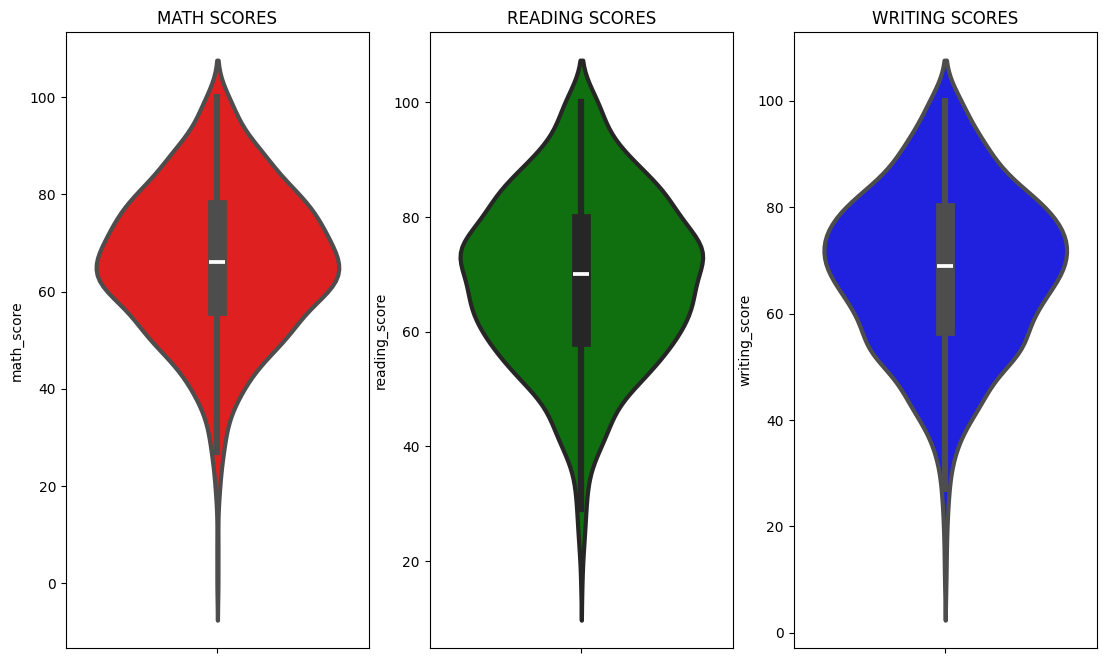

In [40]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()


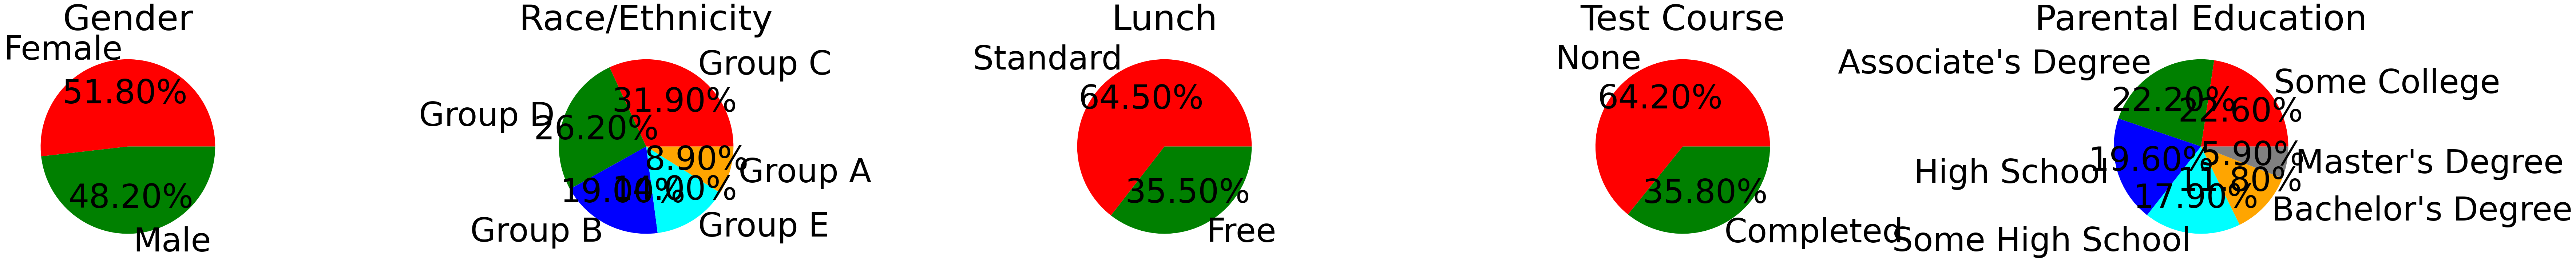

In [57]:
plt.rcParams['figure.figsize'] = (70, 65)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '%.2f%%',textprops={'fontsize':65})
plt.title('Gender', fontsize = 70)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '%.2f%%',textprops={'fontsize':65})
plt.title('Race/Ethnicity', fontsize = 70)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '%.2f%%',textprops={'fontsize':65})
plt.title('Lunch', fontsize = 70)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '%.2f%%',textprops={'fontsize':65})
plt.title('Test Course', fontsize = 70)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '%.2f%%',textprops={'fontsize':65})
plt.title('Parental Education', fontsize = 70)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

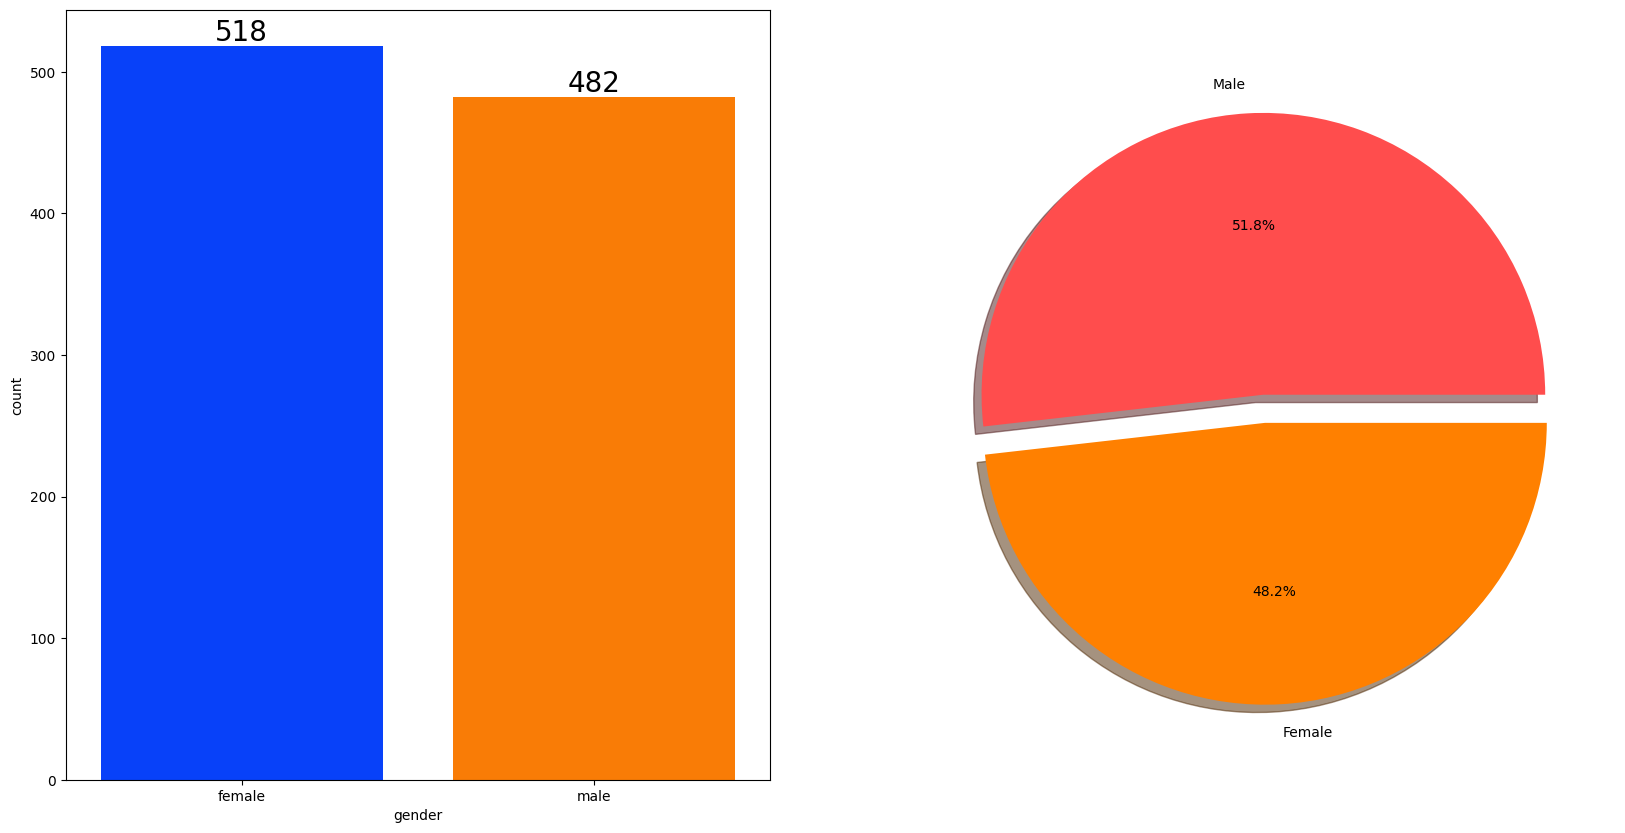

In [ ]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

gender_counts = df['gender'].value_counts()
plt.pie(x=df['gender_counts'],labels=[gender_counts.index],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'],textprops={'fontsize':14})
plt.show()